# Импрорты и нужные классы

In [1]:
import sys
import os
import torch
import copy
import numpy as np
from dotenv import load_dotenv
from pathlib import Path

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / ".env").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
ENV_PATH = os.path.join(PROJECT_ROOT, ".env")

BASE_DIR = PROJECT_ROOT / "experiments" / "loss_coef_exp_31coef"

# sys.path.append('..')
# env_file = os.path.join('..', '.env')
load_dotenv(ENV_PATH)
rowGlam_type = os.environ['ROW_GLAM_TYPE'] # custom or base
name_dataset = os.environ['NAME_DATASET']
name_test_dataset = os.environ['NAME_TEST_DATASET']
dataset_path = os.environ['DATASET_PATH']
test_path = os.environ['TEST_PATH']
test_coco_path = os.environ['TEST_COCO_PATH']
coco_path = os.environ['COCO_PATH']
cache_pdf = os.environ['CASH_PDF_PATH']

In [2]:
from rows2regionsGLAM.utils.pdf_manager import PDFManager
from rows2regionsGLAM.utils.loger import Loger
from rows2regionsGLAM.utils.row_manager import RowManager
from rows2regionsGLAM.utils.ploter import Ploter
from rows2regionsGLAM.utils.trainer import Trainer
from rows2regionsGLAM.utils.tester import Tester
from rows2regionsGLAM.utils.cacher import Cacher
from rows2regionsGLAM.utils.coco_manager import COCOManager
from rows2regionsGLAM.utils.imbalance import calculate_imbalance
from rows2regionsGLAM.utils.tester import collect_maps, print_map_table

from rows2regionsGLAM.models.rowGLAM_base import TorchModelBase, PARAMS_BASE
from rows2regionsGLAM.models.rowGLAM_custom import TorchModel, PARAMS

from rows2regionsGLAM.tokenizers import RowGLAMTokenizer
from rows2regionsGLAM.converters import Rows2Regions
from rows2regionsGLAM.datasetloaders.base_line_dataset import GLAMDataset
from pager.page_model.sub_models.dtype import ImageSegment
from pager.page_model.sub_models import RegionModel, RowsModel

/home/roma/work/PageR/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
loger = Loger(os.path.join(BASE_DIR, 'log.txt'))
pdf_manager = PDFManager(conf={"loger": loger, "pdf_reader": "PDFMiner"})
row_manager = RowManager(conf={"loger": loger, "add_image": True})
coco_manager = COCOManager(conf={"loger": loger, "coco_path": coco_path})
ploter = Ploter(conf={"loger": loger})
tokenizer = RowGLAMTokenizer()
loger(tokenizer.get_name())

pdf2torch_dict = Cacher({
    "loger": loger,
    "pdf_manager": pdf_manager,
    "row_manager": row_manager,
    "tokenizer": tokenizer
})

# Проверка чтения файла

In [4]:
json_true_regions, CLASSES = coco_manager.get_regions_from_json()

In [5]:
CLASSES[3] = "text"
CLASSES

{1: 'text', 2: 'title', 3: 'text', 4: 'table', 5: 'figure', 0: 'other'}

In [6]:
file_names = list(json_true_regions.keys())
file_names.sort()

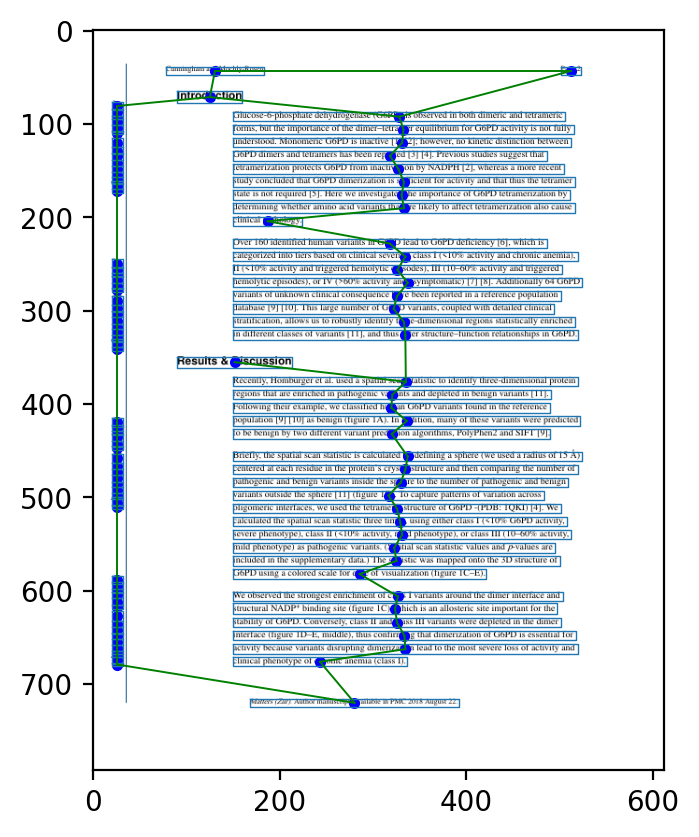

In [7]:
num_file = 9999
file_name = file_names[num_file]
dataset_file = os.path.join(dataset_path, file_name)
pdf_json, pdf_img = pdf_manager.get_json_and_img_from_pdf(dataset_file, num_page=0)
row_json = row_manager.get_row_json_from_pdf_json(pdf_json)
torch_dict = tokenizer(row_json, pdf_img)
ploter.set_dpi(200)
ploter.plot_img(pdf_img)
ploter.plot_tokens(tokenizer, torch_dict)

# Сохранение датасета

In [8]:
dataset = GLAMDataset({
    "loger": loger,
    "pdf_dir": dataset_path,
    "coco_file": coco_path,
    "count_class": len(CLASSES),
    "name_dataset": name_dataset,
    "default_index": 0,
    "cache_dir": cache_pdf,
    "pdf2torch_dict": pdf2torch_dict,
    "to_ROM": True
})

# Создание Cache
N = len(dataset)
for i, d in enumerate(dataset):
    print(f"{(i+1)/N*100:4.2f} %", end='\r')

In [9]:
test_dataset = GLAMDataset(
    {
    "loger": loger,
    "pdf_dir": test_path,
    "coco_file": test_coco_path,
    "count_class": len(CLASSES),
    "name_dataset": name_dataset,
    "default_index": 0,
    "cache_dir": cache_pdf,
    "pdf2torch_dict": pdf2torch_dict,
    "to_ROM": True
    }
)

N = len(test_dataset)
for i, d in enumerate(test_dataset):
    print(f"{(i+1)/N*100:4.2f} %", end='\r')

# Отрисовска файла из датасета

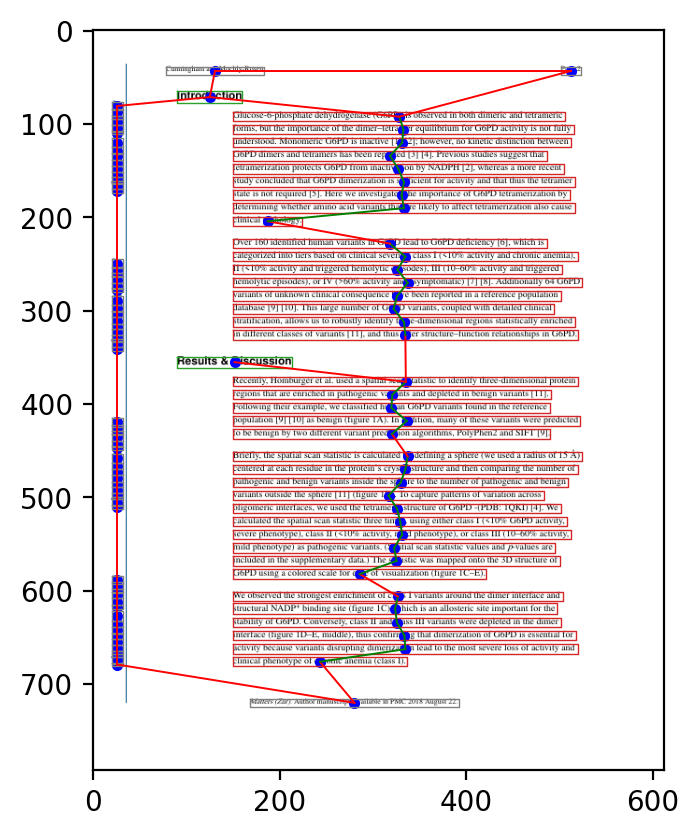

In [10]:
torch_dict2 = dataset[9999]
path_pdf = os.path.join(dataset_path, torch_dict2['file_name'] + ".pdf")
_, img = pdf_manager.get_json_and_img_from_pdf(path_pdf)
ploter.set_dpi(200)
ploter.plot_img(img)
ploter.plot_tokens(tokenizer, torch_dict2, markup=True)

# Параметры эксперимента

In [11]:
EDGE_COEF = [0, 0.005, 0.01, 0.02, 0.03, 0.045, 0.065, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 
     0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.935, 0.955, 0.97, 0.98, 0.99, 0.995, 1]
NODE_COEF = [1, 0.995, 0.99, 0.98, 0.97, 0.955, 0.935, 0.9, 0.85, 0.8, 0.75, 0.7, 0.65, 0.6, 0.55, 0.5, 
     0.45, 0.4, 0.35, 0.3, 0.25, 0.2, 0.15, 0.1, 0.065, 0.045, 0.03, 0.02, 0.01, 0.005, 0]

N = len(EDGE_COEF)

# Вспомогательные функции для сбора метрик

In [12]:
import re
import matplotlib.pyplot as plt
import json
def parse_log(log_path: Path):
    train_losses = []
    val_losses = []

    map_score = None
    f1_row_95 = None

    epoch_pattern = re.compile(
        r"EPOCH\s+#(\d+)\s+([\d.]+)\s+\(VAL:\s+([\d.]+)\)"
    )

    map_pattern = re.compile(
        r"mAP@IoU\[0\.50:0\.95\]\s+:(\d+\.\d+)"
    )

    f1_95_pattern = re.compile(
        r"threshold_95.*?f1_row\s+:(\d+\.\d+)",
        re.DOTALL
    )

    text = log_path.read_text()

    for match in epoch_pattern.finditer(text):
        train_losses.append(float(match.group(2)))
        val_losses.append(float(match.group(3)))

    map_match = map_pattern.search(text)
    if map_match:
        map_score = float(map_match.group(1))

    f1_match = f1_95_pattern.search(text)
    if f1_match:
        f1_row_95 = float(f1_match.group(1))

    return np.array(train_losses), np.array(val_losses), map_score, f1_row_95

def analyze_curves(train_losses, val_losses):
    best_train_epoch = int(np.argmin(train_losses))

    diff = train_losses - val_losses

    sign_change_idx = np.where(np.diff(np.sign(diff)) != 0)[0]

    if len(sign_change_idx) > 0:
        intersection_epoch = int(sign_change_idx[-1])
        intersection_type = "sign_change"
    else:
        intersection_epoch = int(np.argmin(np.abs(diff)))
        intersection_type = "min_distance"

    return best_train_epoch, intersection_epoch, intersection_type


def plot_losses(train_losses, val_losses, intersection_epoch, save_path: Path):
    plt.figure(figsize=(8, 5))

    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")

    plt.axvline(intersection_epoch, linestyle="--", label="Intersection")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Curve")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()

# Запуск эксперимента

In [14]:
for i in range(N):
    if EDGE_COEF[i] == 0 or EDGE_COEF[i] == 1:
        name_edge = '0' if EDGE_COEF[i] == 0 else '1'
        name_node = '0' if NODE_COEF[i] == 0 else '1'
    else:
        name_edge = f'0{str(EDGE_COEF[i])[2:]}'
        name_node = f'0{str(NODE_COEF[i])[2:]}'
    add_str = f'edge{name_edge}_node{name_node}_10k'
    model_name = 'row2region_GLAM_'+add_str
    
    if rowGlam_type == "base":
        model_params = copy.deepcopy(PARAMS_BASE)
    elif rowGlam_type == "custom":
        model_params = copy.deepcopy(PARAMS)
        
    model_params["NodeClasses"] = len(CLASSES)
    
    model_params["batch_size"] = 128

    model_params['loss_params']['edge_coef'] = EDGE_COEF[i]
    model_params['loss_params']['node_coef'] = NODE_COEF[i]
    
    # Дисбаланс классов ------------------------------------
    publaynet_imbalance, edge_imbalance = calculate_imbalance(dataset)
    
    model_params['loss_params']['publaynet_imbalance'] = publaynet_imbalance
    model_params['loss_params']['edge_imbalance'] = edge_imbalance

    # Обучение модели ------------------------------------
    exp_name = add_str
    exp_dir = BASE_DIR / exp_name
    if os.path.isdir(exp_dir):
        continue
    else:
        exp_dir.mkdir(parents=True)
    log_path = Path(os.path.join(exp_dir, 'log.txt'))
    loger_exp = Loger(log_path)
    
    trainer_pub = Trainer(conf={"loger": loger_exp, "params": model_params, "model_name": os.path.join(exp_dir, model_name)})
    trainer_pub.start_train(5, dataset)

    # Тестирование ------------------------------------
    model_params['sigmoidEdge'] = True
    if rowGlam_type == "base":
        model = TorchModelBase(model_params)
    elif rowGlam_type == "custom":
        model = TorchModel(model_params)
    
    model.load_state_dict(torch.load(os.path.join(exp_dir, model_name), weights_only=True))
    
    rows_model = RowsModel()
    region_model = RegionModel()
    rows2regions = Rows2Regions({
        'model':model, 
        'tokenizer': RowGLAMTokenizer(),
        'is_merge_extract': True,
        'classes': CLASSES
    })

    tester = Tester(conf={
        "loger": loger_exp, 
        "pdf_manager": pdf_manager, 
        "row_manager": row_manager, 
        "rows_model": rows_model, 
        "region_model": region_model, 
        "rows2regions": rows2regions})
    
    metrics = tester.calculate_target_and_preds(
        test_dataset, 
        name_dataset, 
        name_test_dataset, 
        dataset_path, 
        test_path
    )
    tester.print_result(metrics)
    
    train_losses, val_losses, map_score, f1_row_95 = parse_log(log_path)
    
    best_train_epoch, intersection_epoch, intersection_type = analyze_curves(train_losses, val_losses)
    
    
    plot_path = exp_dir / "loss_curve.png"
    plot_losses(train_losses, val_losses, intersection_epoch, plot_path)
    
    metrics = {
        "mAP_50_95": map_score,
        "f1_row_threshold_95": f1_row_95,
        "best_train_epoch": best_train_epoch,
        "best_train_loss": float(train_losses[best_train_epoch]),
    
        "intersection_epoch": intersection_epoch,
        "intersection_type": intersection_type,
    
        "best_val_loss": float(np.min(val_losses)),
        "best_val_epoch": int(np.argmin(val_losses)),
    }
    
    metrics_path = exp_dir / "metrics.json"
    with open(metrics_path, "w") as f:
        json.dump(metrics, f, indent=4)


            DATASET INFO:
            count row: 10000
            first: dict_keys(['X', 'Y', 'N', 'inds', 'sp_A', 'true_edges', 'true_nodes', 'file_name'])
            	 A:torch.Size([104, 104])
            	 nodes_feature:torch.Size([104, 15])
            	 edges_feature:torch.Size([151, 4])
            	 true_edges:torch.Size([151])
            end:dict_keys(['X', 'Y', 'N', 'inds', 'sp_A', 'true_edges', 'true_nodes', 'file_name'])
            	 A:torch.Size([107, 107])
            	 nodes_feature:torch.Size([107, 15])
            	 edges_feature:torch.Size([108, 4])
            	 true_edges:torch.Size([108])
        node_featch:	15
edge_featch:	4
epochs:	30
batch_size:	128
learning_rate:	0.001
Tag:	[{'in': -1, 'size': 512, 'out': 512, 'k': 3}, {'in': 512, 'size': 256, 'out': 256, 'k': 3}]
NodeLinear:	[-1, 64, 32]
NodeLinearClassifier:	[-1, 16, 8]
EdgeLinear:	[-1, 16, 4]
batchNormNode:	True
batchNormEdge:	True
seg_k:	0.5
loss_params:	{'edge_coef': 0, 'node_coef': 1, 'publaynet_imba

/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)


/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


...

/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules

/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


mAP@IoU[0.50:0.95]   :0.00191159
threshold_05--------------------
precision_row       :0.1988
recall_row          :0.0551
f1_row              :0.0863
precision_word      :0.1963
recall_word         :0.0560
f1_word             :0.0871
threshold_95--------------------
precision_row       :0.0351
recall_row          :0.0141
f1_row              :0.0201
precision_word      :0.0326
recall_word         :0.0115
f1_word             :0.0170



# Результаты

In [14]:
import os
import sys
import json
import glob
import re
from pathlib import Path

def parse_coefficients(folder_name):
    """
    Парсит название папки для получения edge_coef и node_coef.
    Учитывает специальные случаи, описанные в задании.
    """
    # Специальные случаи по заданию
    if folder_name == 'edge0_node1':
        return 0.0, 1.0
    if folder_name == 'edge1_node1':
        return 1.0, 0.0
    
    # Общий случай: edge<val>_node<val>
    match = re.match(r'edge(.+)_node(.+)', folder_name)
    if match:
        edge_str, node_str = match.groups()
        
        def convert_to_coef(s):
            return float(s) / (10 ** len(s))
        
        return convert_to_coef(edge_str), convert_to_coef(node_str)
    
    return None, None

# Список для хранения результатов
experiments_data = []

# Ищем все файлы metrics.json в папках внутри BASE_DIR
metrics_files = glob.glob(str(BASE_DIR / "edge*" / "metrics.json"))

print(f"BASE_DIR: {BASE_DIR}")
print(f"Найдено файлов метрик: {len(metrics_files)}")

for path in metrics_files:
    path_obj = Path(path)
    folder_name = path_obj.parent.name
    
    try:
        with open(path, 'r', encoding='utf-8') as f:
            metrics = json.load(f)
        
        edge_coef, node_coef = parse_coefficients(folder_name)
        
        if edge_coef is None:
            print(f" Не удалось распарсить коэффициенты для папки: {folder_name}")
            continue
            
        # Извлекаем нужные метрики (с защитой от отсутствия ключей)
        mAP = metrics.get('mAP_50_95', 0.0)
        f1 = metrics.get('f1_row_threshold_95', 0.0)
        
        experiments_data.append({
            'folder': folder_name,
            'edge_coef': edge_coef,
            'node_coef': node_coef,
            'mAP_50_95': mAP,
            'f1_row_threshold_95': f1
        })
        
    except FileNotFoundError:
        print(f" Файл metrics.json не найден в папке: {folder_name} (возможно эксперимент не завершился)")
    except json.JSONDecodeError:
        print(f" Ошибка JSON в папке: {folder_name}")
    except Exception as e:
        print(f" Ошибка обработки {folder_name}: {e}")

# Сортируем результаты: сначала по mAP (убывание), затем по F1 (убывание)
experiments_data.sort(key=lambda x: (x['mAP_50_95'], x['f1_row_threshold_95']), reverse=True)

# Берем топ-15 лучших экспериментов
top_15 = experiments_data[:15]

# В EDGE_COEF записываем только значения edge_coef из топ-15
EDGE_COEF = [exp['edge_coef'] for exp in top_15]

# --- Вывод результатов ---
print("\n" + "="*90)
print(f"ТОП-15 ЛУЧШИХ ЭКСПЕРИМЕНТОВ (по mAP_50_95 и f1_row_threshold_95)")
print("="*90)
print(f"{'#':<3} | {'ПАПКА':<25} | {'EDGE':<6} | {'NODE':<6} | {'mAP 50-95':<10} | {'F1 Thr 95':<10}")
print("="*90)

for i, exp in enumerate(top_15, 1):
    print(f"{i:<3} \t {exp['folder']:<25} \t {exp['edge_coef']:<6.3f} \t {exp['node_coef']:<6.3f} \t {exp['mAP_50_95']:<10.5f} \t {exp['f1_row_threshold_95']:<10.4f}")

print("="*90)
print(f"\n EDGE_COEF (15 лучших edge_coef): {EDGE_COEF}")
print(f" Количество экспериментов: {len(EDGE_COEF)}")

if len(top_15) > 0:
    best = top_15[0]
    print(f"\n АБСОЛЮТНЫЙ ЛИДЕР:")
    print(f"   Папка: {best['folder']}")
    print(f"   Коэффициенты: edge_coef = {best['edge_coef']}, node_coef = {best['node_coef']}")
    print(f"   mAP_50_95: {best['mAP_50_95']}")
    print(f"   f1_row_threshold_95: {best['f1_row_threshold_95']}")
else:
    print("\n Не удалось найти ни одного валидного эксперимента с metrics.json")

BASE_DIR: /home/roma/work/rows2regionsGLAM/experiments/loss_coef_exp_31coef
Найдено файлов метрик: 31

ТОП-15 ЛУЧШИХ ЭКСПЕРИМЕНТОВ (по mAP_50_95 и f1_row_threshold_95)
#   | ПАПКА                     | EDGE   | NODE   | mAP 50-95  | F1 Thr 95 
1   	 edge45_node55             	 0.450  	 0.550  	 0.27099    	 0.5021    
2   	 edge25_node75             	 0.250  	 0.750  	 0.25828    	 0.4618    
3   	 edge65_node35             	 0.650  	 0.350  	 0.25598    	 0.4632    
4   	 edge35_node65             	 0.350  	 0.650  	 0.25121    	 0.4718    
5   	 edge955_node045           	 0.955  	 0.045  	 0.24810    	 0.4736    
6   	 edge9_node1               	 0.900  	 0.100  	 0.24697    	 0.4794    
7   	 edge8_node2               	 0.800  	 0.200  	 0.24576    	 0.4767    
8   	 edge1_node9               	 0.100  	 0.900  	 0.24423    	 0.4561    
9   	 edge7_node3               	 0.700  	 0.300  	 0.24297    	 0.4572    
10  	 edge55_node45             	 0.550  	 0.450  	 0.23802    	 0.4680 

In [15]:
len(EDGE_COEF)

15

In [16]:
EDGE_COEF = sorted(EDGE_COEF)
NODE_COEF = [round(1-e, 3) for e in EDGE_COEF]

N = len(EDGE_COEF)